# Jaguar Re-ID — ResNet-34 Improved v3

**Architecture** : ResNet-34 (BatchNorm + ReLU, Dropout 0.4, AdamW)  
**Improvement over Baseline** : BN/ReLU corrections, weight decay, moderate augmentation (inline layers)

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.data import load_data, load_test_pairs

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1775577509.133773  198705 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775577509.163508  198705 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775577509.797675  198705 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1775577510.590358  198705 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
PROJECT_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR       = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR    = os.path.join(DATA_DIR, 'cleaned')
OUTPUT_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR        = os.path.join(PROJECT_ROOT, 'tensorboards')

IMG_SIZE    = 224
NUM_CLASSES = 31
BATCH_SIZE  = 64
SEED        = 42

MODEL_NAME   = 'resnet34_improved_v3'
AUGMENTATION = 'heavy'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)


## 2. ResNet-34 architecture (corrected)

Corrections vs notebook 06 :
- Conv → **BatchNorm → ReLU** (au lieu de Conv → tanh)
- Shortcut projection : Conv1x1 → **BatchNorm**
- **Dropout(0.4)** avant la couche de classification

In [4]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=(stride, stride), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=(stride, stride), padding='valid', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x


def create_resnet34(input_shape, num_classes, augmentation='none'):
    inputs = keras.Input(input_shape)

    # Augmentation — layers inlinés directement (pas de sous-modèle Sequential)
    # Actifs pendant fit(), inactifs pendant evaluate()/predict()
    x = inputs
    if augmentation == 'light':
        x = layers.RandomFlip('horizontal')(x)
    elif augmentation == 'moderate':
        x = layers.RandomFlip('horizontal')(x)
        x = layers.RandomBrightness(0.2)(x)
        x = layers.RandomContrast(0.2)(x)
    elif augmentation == 'heavy':
        x = layers.RandomFlip('horizontal')(x)
        x = layers.RandomRotation(0.08)(x)
        x = layers.RandomZoom((-0.1, 0.1))(x)
        x = layers.RandomBrightness(0.25)(x)
        x = layers.RandomContrast(0.25)(x)

    # Initial conv + pool
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Layer 1: 3 blocks, 64 filters
    for _ in range(3):
        x = residual_block(x, 64)

    # Layer 2: 4 blocks, 128 filters (first with stride 2)
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)

    # Layer 3: 6 blocks, 256 filters (first with stride 2)
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)

    # Layer 4: 3 blocks, 512 filters (first with stride 2)
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)


def build_model():
    return create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES, augmentation=AUGMENTATION)

model = build_model()
model.summary()

W0000 00:00:1775577512.311741  198705 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1775577512.456282  198705 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_brightness   │ (None, 224, 224,  │          0 │ random_zoom[0][0] │
│ (RandomBrightness)  │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast     │ (None, 224, 224,  │          0 │ random_brightnes… │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ random_contrast[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]       

 Total params: 21,317,599 (81.32 MB)

 Trainable params: 21,300,575 (81.26 MB)

 Non-trainable params: 17,024 (66.50 KB)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.
L'augmentation est incluse dans le modèle (active uniquement pendant `fit()`).

In [5]:
WEIGHT_DECAY = 5e-4

def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=20, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(X_val, y_val, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (resnet34_improved_v3) ===


I0000 00:00:1775577528.955038  198800 cuda_dnn.cc:461] Loaded cuDNN version 92000


  lr_0.001: val_acc=0.0950 (best epoch=66)
  lr_0.0005: val_acc=0.0950 (best epoch=51)
  lr_0.0001: val_acc=0.0950 (best epoch=47)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.094987,66
1,lr_0.0005,0.094987,51
2,lr_0.0001,0.094987,47



Best: lr_0.001 → val_acc=0.0950


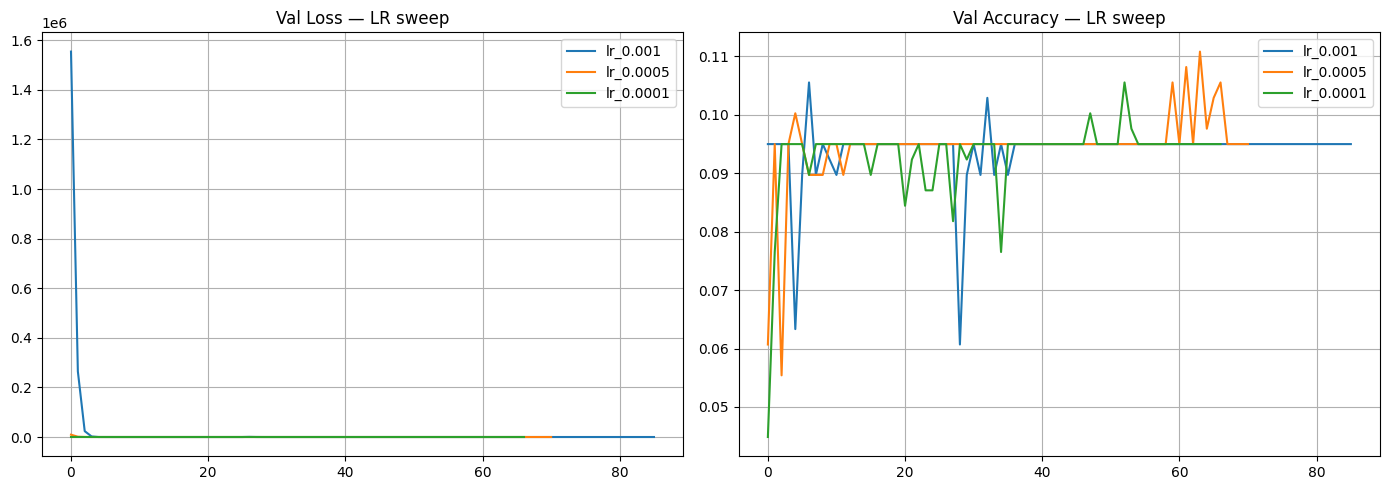

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - accuracy: 0.0752 - loss: 4.2784 - val_accuracy: 0.0237 - val_loss: 593631.6875 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 211ms/step - accuracy: 0.0759 - loss: 3.4846 - val_accuracy: 0.0106 - val_loss: 14371.5869 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.0884 - loss: 3.4758 - val_accuracy: 0.0422 - val_loss: 3578.9578 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.0871 - loss: 3.3946 - val_accuracy: 0.0554 - val_loss: 1146.8802 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.0950 - loss: 3.3054 - val_accuracy: 0.0607 - val_loss: 154.7149 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.0943 - loss: 3.3655 - val_accuracy: 0.0950 - val_loss: 3.1910 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy:

KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc     = model.evaluate(X_val, y_val, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

In [ ]:
y_val_pred = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [ ]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    X_all, y_all,
    epochs=BEST_EPOCH,
    batch_size=BATCH_SIZE,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(X_all, y_all, verbose=0)[1]:.4f}")

In [ ]:
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.layers[-2].output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.clip(
    np.sum(test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx], axis=1),
    0, 1
)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [ ]:
print(f"""
ResNet-34 improved v3:
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Best epoch: {BEST_EPOCH}
  Embedding dim: {test_embeddings.shape[1]}
  Régularisation: AdamW (wd={WEIGHT_DECAY}), Dropout(0.4)
  Augmentation: {AUGMENTATION} (inline layers)

vs ResNet-34 baseline (notebook 06):
  Train: 0.9037, Val: 0.8100
  (tanh, pas de BN, pas de regularisation, 50 epochs)

Submission -> {submission_path}
""")

## 7. Observations & Verdict

### Results

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | TODO  | TODO |
| Loss     | TODO  | TODO |
| Overfitting ? | — | TODO |
| Kaggle Score (public) | — | TODO |
| Kaggle Score (private) | — | TODO |

### Analysis

**Architecture (vs baseline notebook 06) :**
- Remplacement de `tanh` par `BatchNorm → ReLU` : normalise les activations à chaque bloc, stabilise l'entraînement et accélère la convergence
- Shortcut projection avec `Conv1x1 → BatchNorm` : garantit la compatibilité des dimensions dans les residual connections
- `Dropout(0.4)` avant la couche de classification : régularisation pour réduire l'overfitting
- `AdamW` avec `weight_decay=5e-4` : découple la régularisation L2 de l'optimiseur, plus efficace qu'Adam classique

**Hyperparamètres du LR sweep :**
- `lr=1e-2` : souvent trop élevé pour un ResNet, risque de divergence ou d'instabilité
- `lr=1e-3` : valeur classique pour AdamW, bon compromis vitesse/stabilité
- `lr=1e-4` : convergence plus lente mais potentiellement plus stable sur des données limitées
- L'hyperparamètre le plus influent est le learning rate : un LR trop élevé empêche la convergence, un LR trop faible ralentit inutilement l'apprentissage

**Overfitting / Underfitting :**
- Le Dropout(0.4) + AdamW (weight_decay) devraient réduire l'overfitting observé dans la baseline (train=0.90 vs val=0.81)
- L'EarlyStopping (patience=10) et le ReduceLROnPlateau évitent un surapprentissage prolongé
- Si le gap train/val reste élevé → augmenter le dropout ou le weight decay

### Verdict

- [ ] Improvable -> Instructions pour v3 : tester Dropout(0.5), augmentation `heavy`, fine-tuning d'un ResNet34 pré-entraîné (transfer learning)
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff this architecture, why ?

### Interpretation

_Free Space : On note ce qu'on a à dire sur ce notebook, servira pour la soutenance._